# Elastic Net Logistic Regression
Build a single multivariable predictive model that evaluates all patient characteristics simultaneously while controlling for overlap between variables. Helpful because there are many correlated predictors, a relatively modest sample size, sparse categories, and a risk of overfitting.

Instead of estimating coefficients normally, the model:

shrinks weak/unimportant predictors toward 0
keeps the strongest predictors
handles correlated variables better

It combines:

LASSO (L1 penalty) → removes unnecessary variables
Ridge (L2 penalty) → stabilizes correlated predictors

Hence:

Elastic Net=L1 penalty+L2 penalty

## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report

df = pd.read_csv('../../data/processed/cardio_onc_prostate_06_broad_clean.csv')
df["high_risk"] = (
    (df["bp_meds_post_binary"] == 1) |
    (df["lipid_meds_post_binary"] == 1) |
    (df["dm_meds_post_binary"] == 1)
).astype(int)

## Features

In [2]:
features = [
    # Demographics
    "age",
    "bmi",
    "ethnicity_enc",

    # Lifestyle
    "hx_smoking",
    "diet_counseling",
    "exercise_counseling",

    # Baseline disease
    "hx_htn",
    "hx_hld",
    "hx_dm2",
    "hx_cad",
    "hx_mi_stent",
    "hx_chf",
    "hx_arrhythmia",
    "hx_pad",
    "hx_cva",

    # Clinical measurements
    "sbp",
    "dbp",
    "ascvd_10yr",
    "glucose_over_200",

    # Existing meds
    "bp_meds_prior",
    "statin_prior",
    "dm_noninsulin",
    "on_insulin",
    "asa_use",

    # Care utilization
    "has_pcp",
    "cards_prior",
    "cards_referral",
    "echo_ordered",
    "ecg_done",

    # Treatment variables
    "specific_nht_used_enc",
    "adt_agent_enc"
]

## Define and Split

In [3]:
X = df[features]
y = df["high_risk"]

numeric_features = [
    "age",
    "bmi",
    "sbp",
    "dbp",
    "ascvd_10yr"
]

categorical_features = [
    "ethnicity_enc",
    "specific_nht_used_enc",
    "adt_agent_enc"
]

binary_features = [
    col for col in features
    if col not in numeric_features + categorical_features
]

## Preprocessing

In [4]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features)
])

## Elastic Net Model

In [5]:
model = LogisticRegressionCV(
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.1, 0.5, 0.9],
    cv=5,
    scoring="roc_auc",
    max_iter=10000,
    class_weight="balanced"
)

## Pipeline

In [6]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

## Train and Test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

c:\Users\lizbe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\lizbe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Evaluate

In [8]:
pred_probs = pipeline.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, pred_probs)

train_probs = pipeline.predict_proba(X_train)[:,1]

train_auc = roc_auc_score(y_train, train_probs)

print("Train AUC:", train_auc)
print("Test AUC:", auc)

Train AUC: 0.791046626984127
Test AUC: 0.765625


In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

pred_class = (pred_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred_class))
print("Precision:", precision_score(y_test, pred_class))
print("Recall:", recall_score(y_test, pred_class))
print("F1:", f1_score(y_test, pred_class))

Accuracy: 0.7083333333333334
Precision: 0.5384615384615384
Recall: 0.875
F1: 0.6666666666666666


## Identify most Important Predictors

In [10]:
feature_names = (
    numeric_features +
    list(
        pipeline.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_features)
    ) +
    binary_features
)

coefficients = pipeline.named_steps["model"].coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})

# Convert coefficients to odds ratios
importance_df["odds_ratio"] = np.exp(importance_df["coef"])

# Absolute coefficient magnitude for ranking importance
importance_df["abs_coef"] = importance_df["coef"].abs()

# Sort by importance
importance_df = importance_df.sort_values(
    "abs_coef",
    ascending=False
)

importance_df.head(20)

,feature,coef,odds_ratio,abs_coef
33,dm_noninsulin,0.370992,1.449171,0.370992
31,bp_meds_prior,0.254026,1.289205,0.254026
7,ethnicity_enc_2.0,-0.172660,0.841423,0.172660
32,statin_prior,-0.159652,0.852440,0.159652
18,hx_smoking,0.158391,1.171624,0.158391
36,has_pcp,-0.124386,0.883039,0.124386
22,hx_hld,-0.123090,0.884184,0.123090
14,adt_agent_enc_0.0,0.101422,1.106744,0.101422
2,sbp,0.095110,1.099780,0.095110
10,specific_nht_used_enc_0.0,0.082393,1.085882,0.082393


# Visualizations

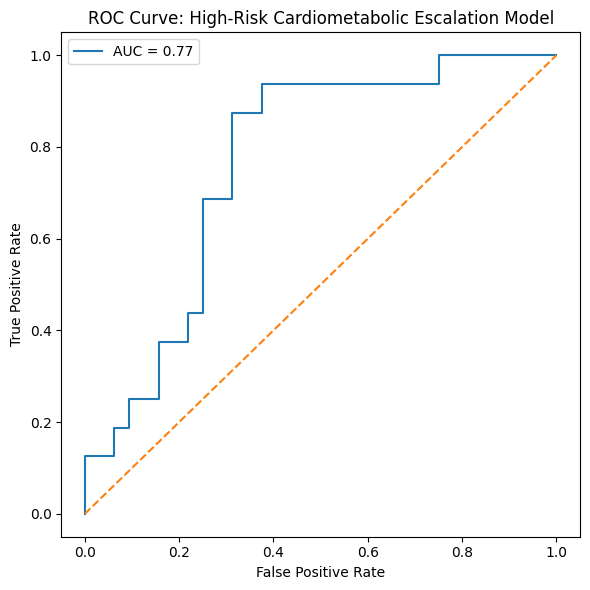

In [11]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, pred_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: High-Risk Cardiometabolic Escalation Model")
plt.legend()
plt.tight_layout()
plt.show()

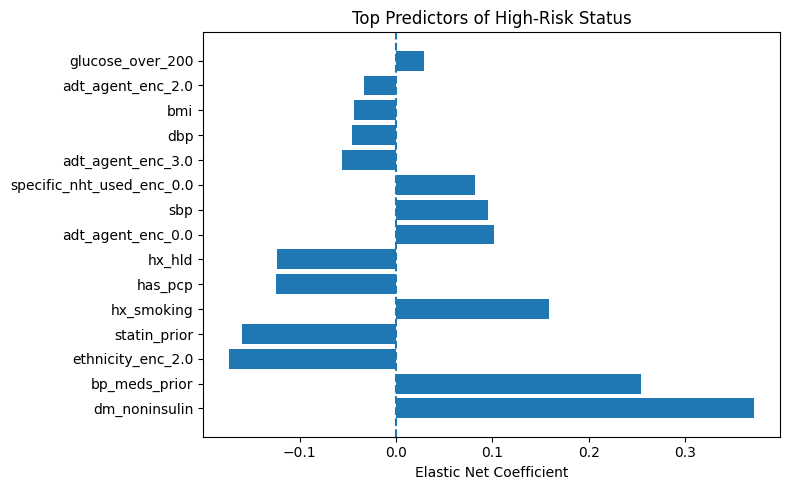

In [12]:
top = importance_df.sort_values(
    "abs_coef",
    ascending=False
).head(15)

plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["coef"])
plt.axvline(0, linestyle="--")
plt.xlabel("Elastic Net Coefficient")
plt.title("Top Predictors of High-Risk Status")
plt.tight_layout()
plt.show()

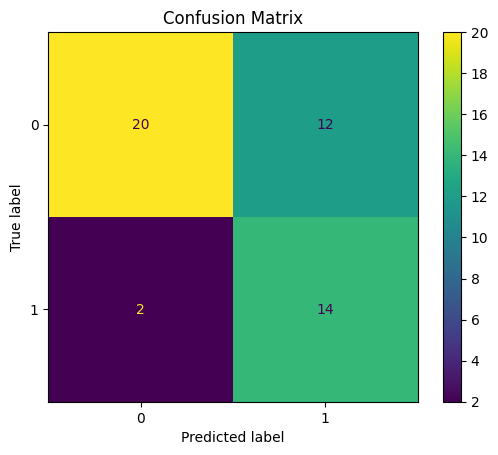

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_class = (pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, pred_class)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Summary
The elastic net logistic regression model demonstrated moderate predictive performance for identifying patients at risk for post-NHT cardiometabolic medication escalation, with a training AUC of 0.79 and test AUC of 0.77, suggesting good generalizability with limited evidence of overfitting. Model accuracy was 70.8%, with high recall/sensitivity (87.5%), indicating strong ability to identify patients who ultimately required escalation of blood pressure, lipid-lowering, or diabetes therapies after treatment. Precision was more modest (53.8%), which is expected in a screening-oriented clinical prediction model where sensitivity is prioritized over specificity. 

The strongest retained predictors of high-risk status included baseline non-insulin diabetes medication use (OR ≈ 1.45), prior antihypertensive therapy (OR ≈ 1.29), smoking history (OR ≈ 1.17), and higher systolic blood pressure (OR ≈ 1.10). In contrast, several variables demonstrated coefficients near zero after penalization, including ASCVD score, age, BMI, and cerebrovascular disease, suggesting relatively limited independent predictive contribution once correlated clinical factors were considered simultaneously. Overall, the model supports the concept that baseline metabolic disease burden and pre-existing cardiometabolic management are the primary drivers of downstream medication escalation following NHT initiation, and demonstrates the feasibility of developing a clinically translatable risk stratification framework for identifying patients who may benefit from enhanced cardio-oncology surveillance or intervention.